In [ ]:
import numpy as np
import os

# path_root = "/Users/timhermans/Documents/GitHub/aslc_intertidal"
path_root = "F:/collaborations/Tim_Hermans/aslc_intertidal"
os.chdir(path_root)

import src.functions as f

def run_trial(path_bin):

    dt = 5/60
    nz, ntrials = 100, 100
    elevation = np.linspace(-2, 2, nz)[::-1]
    amplitude_annual_cycle = np.linspace(0, 2.0, ntrials)
    avg_max_inundation_duration = np.array([np.nan]*nz*ntrials).reshape(nz, ntrials)
    avg_max_emergent_duration   = np.array([np.nan]*nz*ntrials).reshape(nz, ntrials)
    for i in range(ntrials):
        
        time, waterlevel, mean_waterlevel = f.create_waterlevel_timeseries(amplitude_annual_cycle = amplitude_annual_cycle[i], mean_waterlevel = 0., n_years = 2, sigma = 0.013, rho = 0.079, dt = dt)
        avg_max_inundation_duration[:,i], avg_max_emergent_duration[:,i] = f.find_avg_max_duration(elevation, waterlevel, dt)

    # Tile input parameters for saving
    elevation_tiled = np.tile(elevation[:,None], reps = (1, ntrials))
    amplitude_annual_cycle_tiled = np.tile(amplitude_annual_cycle[None,:], reps = (nz, 1))

    np.save(path_bin, [elevation_tiled, amplitude_annual_cycle_tiled, avg_max_inundation_duration, avg_max_emergent_duration])

#################
## Run simulation (Takes time, don't re-run on accident)
#################
# run_trial(path_bin = './bin/supp_note_3/figure_2/figure_2c-alt2.npy')


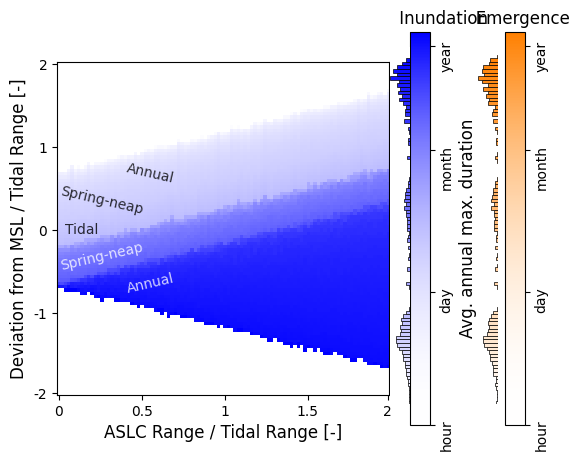

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Rectangle

def panel_a(fig, ax, path_bin):
    
    def blend_arrays(array0, array1, xmin, xmax):

        array0, array1 = np.log10(array0), np.log10(array1)
        
        # Normalize arrays between 0 and 1
        a0 = (array0 - xmin) / (xmax - xmin)
        a1 = (array1 - xmin) / (xmax - xmin)
        a0[np.isnan(a0)] = 0
        a1[np.isnan(a1)] = 0 
        a0[a0 > 1] = 1
        a1[a1 > 1] = 1 
        a0[a0 < 0] = 0
        a1[a1 < 0] = 0 

        # # Create RGB image: R from array1, B from array0, G optional
        # rgb = np.ones((array0.shape[0], array0.shape[1], 3))
        # rgb[..., 0] -= a0   # Red channel = array1
        # rgb[..., 1] -= (a0 + a1*0.5)   # Green channel = array1
        # rgb[..., 2] -= a1   # Blue channel = array0

        # Create RGB image: R from array1, B from array0, G optional
        rgb = np.ones((array0.shape[0], array0.shape[1], 3))
        rgb[..., 1] -= a1*0.5   # Green channel = array1
        rgb[..., 2] -= a1   # Blue channel = array0

        # # Create RGB image: R from array1, B from array0, G optional
        # rgb = np.ones((array0.shape[0], array0.shape[1], 3))
        # rgb[..., 0] -= a0   # Red channel = array1
        # rgb[..., 1] -= a0   # Green channel = array1

        return rgb

    def add_inund_colorbar_historgram(cbar, x, xmin, xmax):
        
        # Create a new Axes next to the colorbar for histogram
        # [left, bottom, width, height] in figure coordinates (0-1 range)
        hist_ax0 = fig.add_axes([0.622, 0.15, 0.03, 0.7])  # adjust position as needed

        bins = np.linspace(xmin, xmax, 100)
        density, bins = np.histogram(np.log10(x), bins = bins, density = True)
        density = density/density.max()

        for x0, x1, y in zip(bins[:-1], bins[1:], density):
            
            a1 = (x1 - xmin) / (xmax - xmin)
            rect = Rectangle((0, x0), y, x1 - x0, transform=hist_ax0.transData, facecolor = (1 - a1,1 - a1,1,1), edgecolor = (0,0,0,1), lw = 0.5)
            hist_ax0.add_patch(rect)

        # Clean up histogram axes
        hist_ax0.set_ylim(cbar.ax.get_ylim())    # Match colorbar scale
        hist_ax0.set_xticks([])
        hist_ax0.set_yticks([])
        hist_ax0.set_xlim(0, 1)
        hist_ax0.invert_xaxis()
        for spine in hist_ax0.spines.values():
            spine.set_visible(False)

    def add_emerg_colorbar_historgram(cbar, x, xmin, xmax):
        
        # Create a new Axes next to the colorbar for histogram
        hist_ax1 = fig.add_axes([0.753, 0.15, 0.03, 0.7])

        bins = np.linspace(xmin, xmax, 100)
        density, bins = np.histogram(np.log10(x), bins = bins, density = True)
        density = density/density.max()

        for x0, x1, y in zip(bins[:-1], bins[1:], density):
            
            a1 = (x1 - xmin) / (xmax - xmin)
            rect = Rectangle((0, x0), y, x1 - x0, transform=hist_ax1.transData, facecolor = (1,1 - a1*0.5,1 - a1,1), edgecolor = (0,0,0,1), lw = 0.5)
            hist_ax1.add_patch(rect)

        # Clean up histogram axes
        hist_ax1.set_ylim(cbar.ax.get_ylim())    # Match colorbar scale
        hist_ax1.set_xticks([])
        hist_ax1.set_yticks([])
        hist_ax1.set_xlim(0, 1)
        hist_ax1.invert_xaxis()
        for spine in hist_ax1.spines.values():
            spine.set_visible(False)

    # Define RGBA start and end colors
    start = (1, 1, 1, 0)
    blue = (0, 0, 1, 1)
    orange = (1., 0.5, 0., 1)

    # Create custom colormap
    cmap0 = LinearSegmentedColormap.from_list("transparent_to_blue", [start, blue])
    cmap1 = LinearSegmentedColormap.from_list("transparent_to_orange", [start, orange])

    dt = 5/60
    z, aslc, inund_max, emerg_max = np.load(path_bin)

    nz, ntrials = z.shape

    inund_max[inund_max == 0] = np.nan
    emerg_max[emerg_max == 0] = np.nan
    subset = np.isnan(inund_max) | np.isnan(emerg_max)
    inund_max[subset] = np.nan
    emerg_max[subset] = np.nan

    xmin, xmax = np.log10(1/24), np.log10(365.25*1.4)

    rgb = blend_arrays(inund_max, emerg_max, xmin, xmax)
    ax.imshow(rgb, vmin = xmin, vmax = xmax)

    # Create dummy mappables for colorbars
    norm = plt.Normalize(vmin = xmin, vmax = xmax)
    mappable_emerg = ScalarMappable(norm=norm, cmap=cmap1)   # Orange
    mappable_inund = ScalarMappable(norm=norm, cmap=cmap0)   # Blue
    
    cbar1 = fig.colorbar(mappable_emerg, ax=ax)
    cbar1.ax.set_yticks(ticks = [np.log10(1/24),np.log10(1),np.log10(30),np.log10(365.25)], labels = ['hour','day', 'month', 'year'])
    # cbar1.ax.set_yticks(ticks = [np.log10(6.125/24),np.log10(14.8/2),np.log10(365.25/2)], labels = ['tidal','spring-neap', 'annual'])
    cbar1.ax.tick_params(axis = 'y', labelrotation = 90)
    cbar1.ax.set_title('   Emergence', fontsize=12)
    pos = cbar1.ax.get_position()
    new_pos = [pos.x0 + 0.01, pos.y0, pos.width, pos.height]
    cbar1.ax.set_position(new_pos)
    add_emerg_colorbar_historgram(cbar1, emerg_max, xmin, xmax)
    

    # Add colorbars using dummy mappables
    cbar0 = fig.colorbar(mappable_inund, ax=ax)
    cbar0.ax.set_ylabel('Avg. annual max. duration', fontsize=12)
    cbar0.ax.set_yticks(ticks = [np.log10(1/24),np.log10(1),np.log10(30),np.log10(365.25)], labels = ['hour','day', 'month', 'year'])
    # cbar0.ax.set_yticks(ticks = [np.log10(6.125/24),np.log10(14.8/2),np.log10(365.25/2)], labels = ['tidal','spring-neap', 'annual'])
    cbar0.ax.tick_params(axis = 'y', labelrotation = 90)
    cbar0.ax.set_title('         Inundation', fontsize=12)
    add_inund_colorbar_historgram(cbar0, inund_max, xmin, xmax)


    ax.set_xlabel('ASLC Range / Tidal Range [-]', fontsize = 12)
    ax.set_ylabel('Deviation from MSL / Tidal Range [-]', fontsize = 12)
    ax.set_xticks(ticks = [0, 25, 50, 75, 99], labels = [0, 0.5, 1, 1.5, 2])
    ax.set_yticks(ticks = [0, 25, 50, 75, 99], labels = [2, 1, 0, -1, -2])

    # subtidal, supratidal = 32, 67
    # emerge_springneap, emerge_annual = 36, 48
    # inund_springneap, inund_annual = 63, 51
    # ax.plot([0, ntrials - 1], [subtidal,         subtidal - 23],         c = 'black', alpha = 1)
    # ax.plot([0, ntrials - 1], [supratidal,       supratidal + 23],       c = 'black', alpha = 1)
    # ax.plot([0, ntrials - 1], [emerge_springneap,emerge_springneap + 23],c = 'black', lw = 1, alpha = 0.1, zorder = 0)
    # ax.plot([0, ntrials - 1], [emerge_annual,    emerge_annual + 23],    c = 'black', lw = 1, alpha = 0.1, zorder = 0)
    # ax.plot([0, ntrials - 1], [inund_springneap, inund_springneap - 23], c = 'white', lw = 1, alpha = 0.1, zorder = 0)
    # ax.plot([0, ntrials - 1], [inund_annual,     inund_annual - 23],     c = 'white', lw = 1, alpha = 0.1, zorder = 0)

    ax.text(20, 33, s = 'Annual',      rotation = -13, c = 'black', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text( 0, 41, s = 'Spring-neap', rotation = -13, c = 'black', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text( 2, 50, s = 'Tidal',       rotation =   0, c = 'black', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text( 0, 58, s = 'Spring-neap', rotation =  13, c = 'white', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)
    ax.text(20, 66, s = 'Annual',      rotation =  13, c = 'white', alpha = 0.8, verticalalignment = 'center', fontsize = 10, zorder = 1)

def figure_multipanel(path_bin, path_png = None):

    rows, cols = 1, 1
    fig = plt.figure(figsize=((6.4 + 0.3)*cols,(4.8 + 0.3)*rows))
    gs = fig.add_gridspec(rows, cols, hspace=.15, wspace=.15) 

    ax = fig.add_subplot(gs[0,0])
    panel_a(fig, ax, path_bin)
    if path_png is not None:
        plt.savefig(path_png, dpi = 300, bbox_inches = "tight", pad_inches = 0.2)
    plt.show()

figure_multipanel(path_bin = './bin/supp_note_3/figure_2/figure_2c-alt2.npy', path_png = './figures/supp_note_3/figure_2/figure_2c-alt2-emergence.png')